In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("../Data/dataset.csv")

In [4]:
df.head(10)

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17
0,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Fungal infection,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Fungal infection,itching,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Fungal infection,itching,skin_rash,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,Fungal infection,itching,skin_rash,nodal_skin_eruptions,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,Fungal infection,itching,skin_rash,nodal_skin_eruptions,dischromic _patches,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:

# Basic info
print(df.shape)
print(df.head())
print(df.info())
print(df.describe())

(4920, 18)
            Disease   Symptom_1              Symptom_2              Symptom_3  \
0  Fungal infection     itching              skin_rash   nodal_skin_eruptions   
1  Fungal infection   skin_rash   nodal_skin_eruptions    dischromic _patches   
2  Fungal infection     itching   nodal_skin_eruptions    dischromic _patches   
3  Fungal infection     itching              skin_rash    dischromic _patches   
4  Fungal infection     itching              skin_rash   nodal_skin_eruptions   

              Symptom_4 Symptom_5 Symptom_6 Symptom_7 Symptom_8 Symptom_9  \
0   dischromic _patches       NaN       NaN       NaN       NaN       NaN   
1                   NaN       NaN       NaN       NaN       NaN       NaN   
2                   NaN       NaN       NaN       NaN       NaN       NaN   
3                   NaN       NaN       NaN       NaN       NaN       NaN   
4                   NaN       NaN       NaN       NaN       NaN       NaN   

  Symptom_10 Symptom_11 Symptom_12 Symp

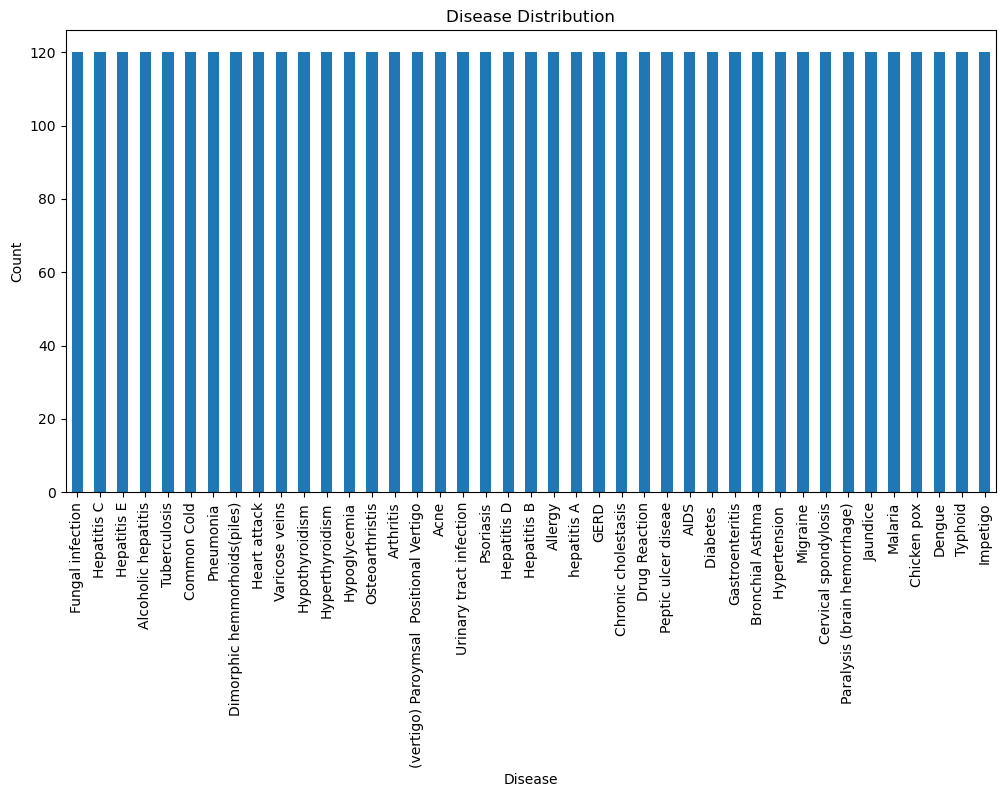

In [6]:

df['Disease'].value_counts().plot(kind='bar', figsize=(12,6))
plt.title("Disease Distribution")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()


In [7]:
symptom_cols = df.columns[1:]

symptoms = set()
for col in symptom_cols:
    symptoms.update(df[col].dropna().unique())

print("Total unique symptoms:", len(symptoms))

Total unique symptoms: 131


In [8]:
from collections import Counter

symptom_counter = Counter()

for col in symptom_cols:
    symptom_counter.update(df[col].dropna())

# Convert to DataFrame
symptom_df = pd.DataFrame(symptom_counter.items(), columns=["Symptom", "Count"])
symptom_df = symptom_df.sort_values(by="Count", ascending=False)

print(symptom_df.head())

              Symptom  Count
10            fatigue   1932
6            vomiting   1914
33         high_fever   1362
36   loss_of_appetite   1152
42             nausea   1146


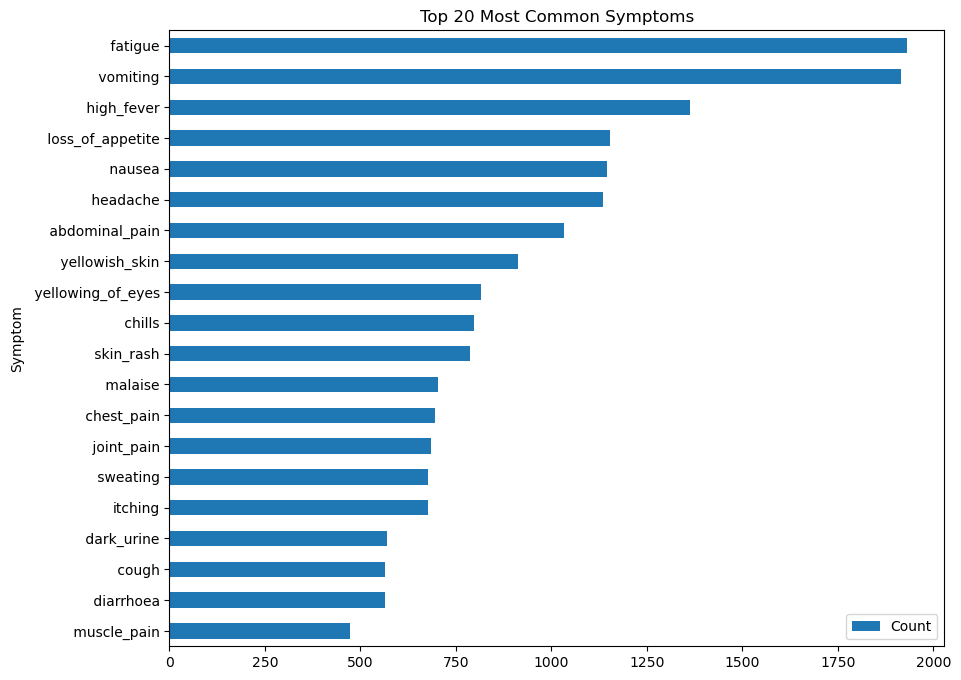

In [9]:
symptom_df.head(20).plot(kind='barh', x='Symptom', y='Count', figsize=(10,8))
plt.title("Top 20 Most Common Symptoms")
plt.gca().invert_yaxis()
plt.show()


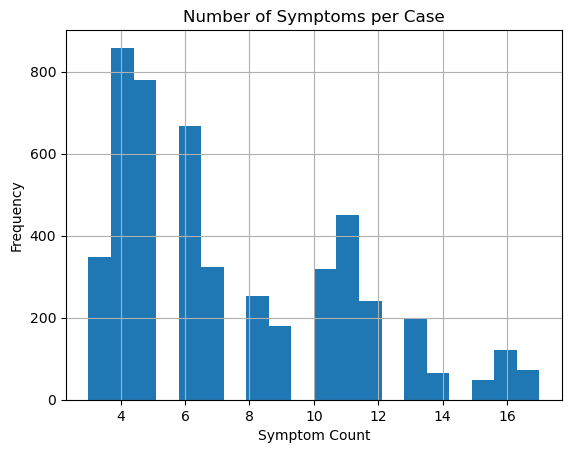

In [10]:
df['num_symptoms'] = df.iloc[:,1:].count(axis=1)

df['num_symptoms'].hist(bins=20)
plt.title("Number of Symptoms per Case")
plt.xlabel("Symptom Count")
plt.ylabel("Frequency")
plt.show()

In [11]:
df[df['Disease'] == 'Malaria']

,Disease,Symptom_1,Symptom_2,Symptom_3,Symptom_4,Symptom_5,Symptom_6,Symptom_7,Symptom_8,Symptom_9,Symptom_10,Symptom_11,Symptom_12,Symptom_13,Symptom_14,Symptom_15,Symptom_16,Symptom_17,num_symptoms
150,Malaria,chills,vomiting,high_fever,sweating,headache,nausea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
151,Malaria,chills,vomiting,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
152,Malaria,chills,vomiting,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
153,Malaria,vomiting,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
154,Malaria,chills,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4730,Malaria,chills,vomiting,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
4771,Malaria,chills,vomiting,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
4812,Malaria,chills,vomiting,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8
4853,Malaria,chills,vomiting,high_fever,sweating,headache,nausea,diarrhoea,muscle_pain,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8


In [12]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 4616
